---

# Individual Assignment Example: **Telco Customer Churn Prediction** (worked solution)

**Dataset (required):** “Telco Customer Churn” — public dataset used by IBM / available on Kaggle / OpenML. ([Kaggle][1])

---

## 1) Business context & problem statement

**Organization / domain:** A mid-sized telecom operator providing broadband, phone and multiple subscription options across the US.

**Business problem:** Predict which customers are likely to churn (i.e., cancel service) in the next month so the retention team can target high-risk customers with offers and save revenue.

**Why use Advanced Predictive Analytics?**

* The problem is high-impact (lost revenue, CLTV reduction) and data is multi-modal (demographics, account info, service flags, tenure, payments).
* Non-linear relationships, categorical interactions (e.g., Contract × PaymentMethod), and class imbalance make advanced tree-based ensembles / model explainability important.
* A simple rule (e.g., tenure < 3 months) is insufficient for accurate targeting; robust probabilistic models + explainability (SHAP) are required for trustworthy CXO decisions.

**Business objective (metric):** Maximize expected retained revenue = (Precision or Precision@k for top N targeted customers) × estimated average CLTV — but also track ROC-AUC and Recall to understand overall classifier quality.

---

## 2) Deliverables (what the student must hand in)

* Cleaned **raw dataset** (CSV/XLSX) used (original file or link + any derived files). *(Mandatory.)*
* **Code notebook** (Python or R) that reproduces all steps.
* **Report** (12–15 pages) covering business problem, EDA, feature engineering, modelling, evaluation, interpretation, and recommendations.
* **Presentation** (≤10 slides) summarizing problem, top insights, final model performance, and rollout recommendations.

---

## 3) Data understanding (what’s in the Telco dataset)

Typical columns (students should produce a data dictionary):
`customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `tenure`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`, `Churn` (target). ([Kaggle][1])

**Key summary (precomputed from dataset docs):** ~7,043 customers; churn rate ≈ 26–27% (students should compute exact percent in class). ([IBM][2])

---

## 4) Exploratory Data Analysis (EDA) — what to do & example findings

**Steps students must do:**

* Show `shape`, `dtypes`, missing value counts.
* Univariate distributions (histograms for numeric, bar charts for categorical).
* Bivariate analysis versus `Churn` (proportions & boxplots).
* Correlation matrix for numeric features; Cramér’s V / χ² for categorical associations.
* Check class imbalance and tenure distribution; check `TotalCharges` anomalies.
* Detect outliers and improbable values (zero tenure with >0 charges, etc).

**Example EDA insights to show in class (illustrative):**

* `Churn` is concentrated among short-tenure customers (tenure < 12 months).
* Contract type: month-to-month customers churn far more than one- or two-year contract customers.
* Higher `MonthlyCharges` sometimes correlates with higher churn — possibly customers with expensive add-ons are more sensitive.
* PaymentMethod & PaperlessBilling may show association with churn (paperless + electronic payment sometimes correlates with higher churn in this dataset).

(Students should back each insight with a plot and % numbers.)

---

## 5) Feature engineering — recommended pipeline & rationale

**Missing values and cleaning**

* `TotalCharges` may be blank for some customers — convert to numeric and impute (e.g., 0 or median depending on tenure). Remove rows if inconsistent after investigation.

**Encoding**

* Binary variables: map `Yes`/`No` → 1/0.
* Multi-category variables: one-hot encode `InternetService`, `Contract`, `PaymentMethod` OR use target-encoding for high-cardinality features if necessary.

**Derived features**

* `TenureGroup` buckets (0–6, 7–12, 13–24, 25+).
* `AvgChargesPerMonth = TotalCharges / max(1, tenure)` to capture lifetime spend trend.
* Interaction terms: `Contract × MonthlyCharges`; `InternetService × StreamingTV`.
* `NumServices` = count of service flags (OnlineSecurity, DeviceProtection, etc) — a compact signal of intensity.

**Scaling**

* Tree-based models do not require scaling; for Logistic / Neural nets, apply `StandardScaler` to numeric features.

**Address class imbalance**

* Use stratified sampling for train/test splits. Consider class weighting or upsampling/SMOTE for some models (but test with/without to measure impact).

**Document everything**: transformation applied, exact code, and reason why each transformation was done.

---

## 6) Modelling — candidate models, evaluation, and champion/challenger process

**Model set (minimum 3):**

1. **Baseline:** Logistic Regression with L2 regularization (interpretable, fast).
2. **Tree ensemble challenger:** Random Forest with class weights.
3. **Advanced challenger:** Gradient Boosting (e.g., XGBoost or LightGBM).
4. *(Optional / for advanced students)* Neural Network (small MLP) or survival model if doing retention/time-to-event analysis.

**Training/validation approach**

* Split data: Train (60%), Validation (20%), Test (20%) with stratification on `Churn`. Alternatively use nested CV for hyperparameter tuning and a final hold-out test set.
* Use hyperparameter tuning (GridSearchCV or Bayesian tuner) on Validation or via CV.
* Use early stopping for boosting models to avoid overfitting.

**Evaluation metrics (use multiple)**

* Primary classification metrics: **ROC-AUC**, **Precision**, **Recall**, **F1**.
* Business metric: **Precision@K** for top K customers to send retention offers (e.g., top 1,000).
* Confusion matrix to show tradeoffs (False Positives = wasted offer spend; False Negatives = lost customers).

**Champion–Challenger framework**

* **Champion = current production or baseline model** (in class use Logistic Regression or simple decision tree as Champion).
* **Challengers = Random Forest, XGBoost**.
* Compare models across: training performance, validation performance, and final hold-out test set.
* Check calibration (do predicted probabilities align with observed churn rates?). Use isotonic or Platt scaling if needed.
* Use business-focused comparison: for a fixed marketing budget (target N customers), which model yields the highest expected saved revenue? (compute expected gains using Precision@N × avg CLTV).

**Model selection rationale example (what to show)**

* If XGBoost achieves higher ROC-AUC and better Precision@K on the test set, and its predictions are explainable via SHAP, it becomes the Champion. But if its improvement is marginal and interpretability matters a lot, the simpler model may remain Champion.

*(Note: I am not reporting concrete numeric scores here — in class, compute actual metrics live from the notebook to demonstrate.)*

---

## 7) Model explainability — how to make it CXO friendly

**Explainability steps**

* Feature importance (tree-based) for a quick leaderboard.
* **SHAP** values for local and global interpretation: show which features push a prediction toward churn vs retention.
* Partial Dependence Plots for top features (e.g., effect of tenure on churn probability).

**CXO slide** (example bullets)

* “Top 5 drivers of churn: Contract type (month-to-month), Tenure, MonthlyCharges, InternetService type, PaperlessBilling.”
* “Targeting the top 2,000 high-risk customers identified by the XGBoost model (Precision@2000 = X%) is expected to save $Y of revenue over 6 months.” *(Students must compute X and Y using dataset CLTV proxies.)*

---

## 8) Champion–Challenger test across samples (what to present)

* Show a table with metrics on Train / Validation / Test for each model (ROC-AUC, Precision@K, Recall).
* Show lift chart and cumulative gains: how many churners are captured in top deciles.
* Demonstrate calibration curve.
* For operational testing, propose an A/B test in production: randomize retention offer to top-scored customers vs rule-based targeting; measure uplift in retention rate over a chosen horizon (e.g., 3 months).

---

## 9) Business insights & CXO summary (what to present in final slides)

* 3–5 one-line insights (non-technical), e.g.:

  1. “Month-to-month customers with tenure < 6 months and high monthly charges are 3× more likely to churn than average.”
  2. “Customers with no online security add-on churn at higher rates — cross-sell a low-cost security bundle to reduce churn.”
  3. “Paperless billing customers show higher churn — review communication cadence & invoices clarity.”
* Visual: single page dashboard showing churn rate, top risk segments, top model drivers, and recommended actions.

---

## 10) Recommendations & implementation roadmap

**Short term (0–3 months)**

* Deploy prediction model as a batch scoring job weekly; export top N target list to retention marketing.
* Run an **A/B test**: model-based targeting vs current rule-based approach to measure lift on retention over 3 months.

**Medium term (3–9 months)**

* Build real-time scoring for contact center – when a high-risk customer calls, the agent sees the churn risk and recommended offer.
* Integrate model output into CRM; create target pipelines and monitor model drift.

**Monitoring & governance**

* Track Precision@K, recall of top deciles, monthly churn rate, and model calibration.
* Retrain model when performance drops beyond a threshold (e.g., ROC-AUC drop of 3–5%) or quarterly.

**Risks & limitations**

* Model trained on historical patterns — product changes or pricing changes can alter behavior (data drift).
* Dataset is (public / fictional) sample — if applying to a live telco, re-train on company’s proprietary data and validate legal/privacy constraints.

---

--------------
## Telco Customer Churn — End-to-End Worked Solution

**Purpose:** This notebook is a fully-documented, runnable end-to-end worked solution for the Mid-Term assignment used in the Advanced Predictive Analytics course. It covers business context, EDA, feature engineering, model tuning, Champion–Challenger evaluation, explainability, business KPIs (Precision@K), revenue estimation, and CXO-ready outputs.

**How to run:**
1. Download the dataset `WA_Fn-UseC_-Telco-Customer-Churn.csv` from Kaggle (https://www.kaggle.com/blastchar/telco-customer-churn) and place it in the same folder as this notebook. Alternatively, upload the file if running on Google Colab.
2. Run cells sequentially. Cells include checks and helpful instructions. Some optional steps (XGBoost, SHAP) require extra packages.

**Note:** This notebook trains Logistic Regression and Random Forest by default (these do not require external packages beyond scikit-learn). XGBoost is optional — if installed, the notebook will tune it as well.


## 1) Imports and Environment Setup

This cell imports core libraries and provides `pip install` hints for optional packages.

In [ ]:

# Optional installs for full functionality (uncomment if needed)
# !pip install scikit-learn xgboost shap matplotlib seaborn pandas python-pptx pillow

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print('Core libraries loaded. Python version:', sys.version.split()[0])


## 2) Data Loading and Quick Checks

We load the Telco dataset and run initial sanity checks (shape, missing values, basic stats).

In [7]:

DATA_FILE = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
if not os.path.exists(DATA_FILE):
    print(f"Dataset '{DATA_FILE}' not found in {os.getcwd()}.")
    print('Please download the file from Kaggle and place it in this folder, then re-run this cell.')
    df = None
else:
    df = pd.read_csv(DATA_FILE)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print('Loaded dataset with shape:', df.shape)
    display(df.head())
    print('\nMissing values per column:')
    display(df.isna().sum())
    print('\nTarget distribution (Churn):')
    display(df['Churn'].value_counts(normalize=True))


Loaded dataset with shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Missing values per column:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Target distribution (Churn):


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## 3) Exploratory Data Analysis (EDA)

Why: EDA helps understand distributions, class balance, and relationships that inform feature engineering and modelling choices.

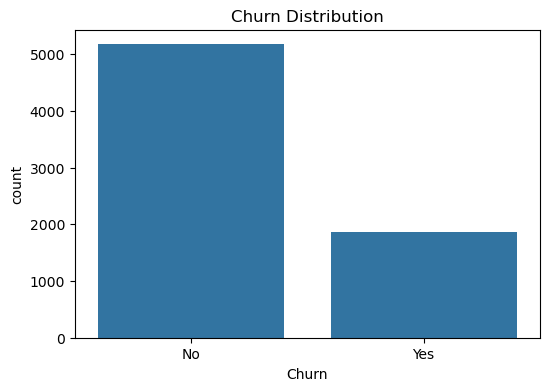

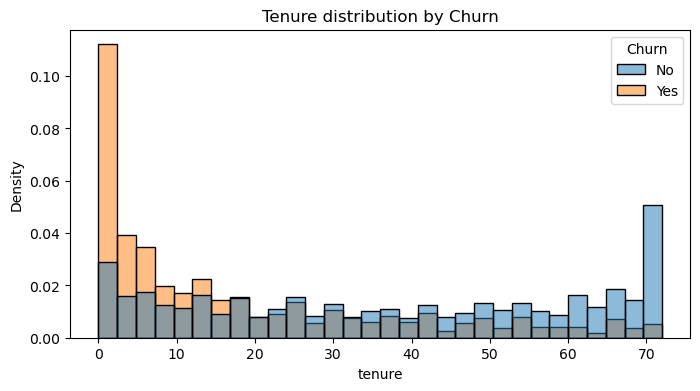

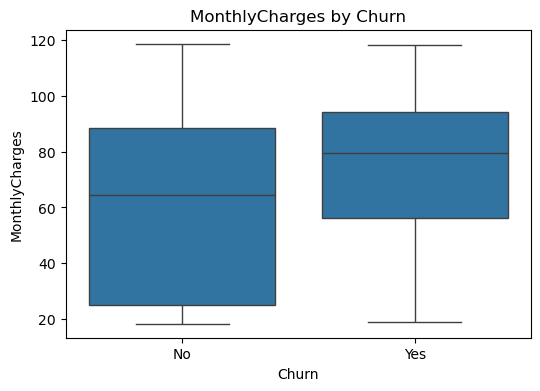

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


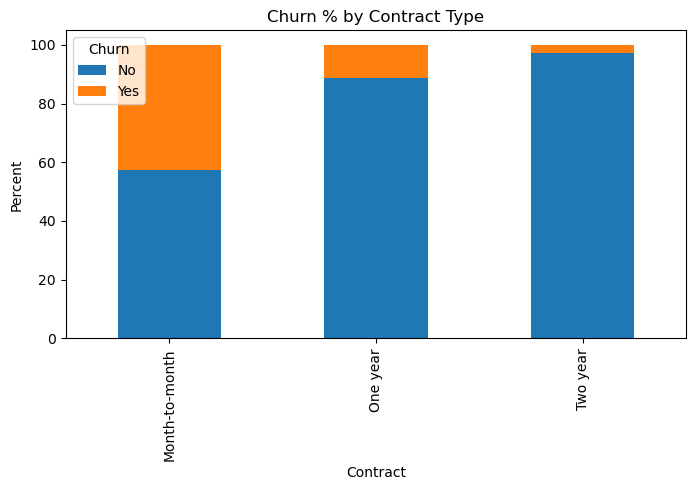

TotalCharges null count: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [12]:

if df is None:
    print('Dataset not loaded - please place the CSV and re-run.')
else:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Churn', data=df)
    plt.title('Churn Distribution')
    plt.show()

    plt.figure(figsize=(8,4))
    sns.histplot(df, x='tenure', hue='Churn', bins=30, stat='density', common_norm=False)
    plt.title('Tenure distribution by Churn')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
    plt.title('MonthlyCharges by Churn')
    plt.show()

    contract_ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100
    display(contract_ct.round(2))
    contract_ct.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.ylabel('Percent')
    plt.title('Churn % by Contract Type')
    plt.show()

    print('TotalCharges null count:', df['TotalCharges'].isna().sum())
    display(df[df['TotalCharges'].isna()].head())


## 4) Feature Engineering & Preprocessing

Why: Transform raw variables into model-ready features and create meaningful derived features (e.g., `num_services`, `avg_charges_per_month`).

In [15]:

if df is None:
    print('Dataset missing.')
else:
    df_proc = df.copy()
    df_proc['TotalCharges'] = df_proc['TotalCharges'].fillna(0)
    yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
    for c in yes_no_cols:
        df_proc[c] = df_proc[c].map({'Yes':1,'No':0})
    df_proc['SeniorCitizen'] = df_proc['SeniorCitizen'].astype(int)
    service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','MultipleLines']
    for c in service_cols:
        df_proc[c] = df_proc[c].replace({'No internet service':'No', 'No phone service':'No'})
        df_proc[c] = df_proc[c].map({'Yes':1,'No':0})
    df_proc['num_services'] = df_proc[service_cols].sum(axis=1)
    df_proc['avg_charges_per_month'] = df_proc.apply(lambda r: r['TotalCharges']/r['tenure'] if r['tenure']>0 else r['MonthlyCharges'], axis=1)
    df_proc['ChurnFlag'] = df_proc['Churn'].map({'Yes':1,'No':0})
    cat_cols = ['gender','InternetService','Contract','PaymentMethod']
    df_final = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)
    feature_cols = ['SeniorCitizen','Partner','Dependents','tenure','MonthlyCharges','TotalCharges','num_services','avg_charges_per_month','PaperlessBilling'] +                    [c for c in df_final.columns if c.startswith('InternetService_') or c.startswith('Contract_') or c.startswith('PaymentMethod_') or c.startswith('gender_')]
    X = df_final[feature_cols]
    y = df_final['ChurnFlag']
    print('Feature matrix shape:', X.shape)
    display(X.head())


Feature matrix shape: (7043, 17)


,SeniorCitizen,Partner,Dependents,tenure,MonthlyCharges,TotalCharges,num_services,avg_charges_per_month,PaperlessBilling,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,29.85,29.85,1,29.850000,1,False,False,False,False,False,False,True,False
1,0,0,0,34,56.95,1889.50,2,55.573529,0,True,False,False,True,False,False,False,True
2,0,0,0,2,53.85,108.15,2,54.075000,1,True,False,False,False,False,False,False,True
3,0,0,0,45,42.30,1840.75,3,40.905556,0,True,False,False,True,False,False,False,False
4,0,0,0,2,70.70,151.65,0,75.825000,1,False,True,False,False,False,False,True,False


## 5) Train / Validation / Test Split

Why: We hold out a test set for final unbiased evaluation and use cross-validation during hyperparameter tuning.

In [18]:

if df is None:
    print('Dataset missing.')
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
    print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
    print('Train churn rate:', y_train.mean(), 'Test churn rate:', y_test.mean())


Train shape: (5634, 17) Test shape: (1409, 17)
Train churn rate: 0.2653532126375577 Test churn rate: 0.2654364797728886


## 6) Model Tuning with GridSearchCV

We tune Logistic Regression and Random Forest using GridSearchCV (scoring by ROC-AUC). XGBoost is optional and will be tuned if installed.

In [21]:

# Logistic Regression pipeline + GridSearch
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])
param_lr = {'lr__C':[0.01,0.1,1,10]}
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print('Best LR params:', grid_lr.best_params_)
probs_lr = best_lr.predict_proba(X_test)[:,1]
preds_lr = (probs_lr >= 0.5).astype(int)


Best LR params: {'lr__C': 1}


In [23]:

# Random Forest GridSearch
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
param_rf = {'n_estimators':[100,200], 'max_depth':[5,10,None], 'min_samples_split':[2,5]}
grid_rf = GridSearchCV(rf, param_rf, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print('Best RF params:', grid_rf.best_params_)
probs_rf = best_rf.predict_proba(X_test)[:,1]
preds_rf = (probs_rf >= 0.5).astype(int)


Best RF params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [24]:

# XGBoost GridSearch 
try:
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc', random_state=42)
    param_xgb = {'n_estimators':[100,200], 'max_depth':[3,5], 'learning_rate':[0.01,0.1]}
    grid_xgb = GridSearchCV(xgb_model, param_xgb, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
    grid_xgb.fit(X_train, y_train)
    best_xgb = grid_xgb.best_estimator_
    print('Best XGB params:', grid_xgb.best_params_)
    probs_xgb = best_xgb.predict_proba(X_test)[:,1]
    preds_xgb = (probs_xgb >= 0.5).astype(int)
except Exception as e:
    print('XGBoost not available or failed to run:', e)
    best_xgb = None
    probs_xgb = None
    preds_xgb = None


Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 7) Model Evaluation & Champion Selection

Compute metrics for each tuned model on the hold-out test set and select the Champion using ROC-AUC and business metrics.

In [29]:

# Build results table for available models
results = []
# Logistic Regression
lr_row = {
    'model':'LogisticRegression',
    'roc_auc': roc_auc_score(y_test, probs_lr),
    'precision': precision_score(y_test, preds_lr),
    'recall': recall_score(y_test, preds_lr),
    'f1': f1_score(y_test, preds_lr)
}
results.append(lr_row)

# Random Forest
rf_row = {
    'model':'RandomForest',
    'roc_auc': roc_auc_score(y_test, probs_rf),
    'precision': precision_score(y_test, preds_rf),
    'recall': recall_score(y_test, preds_rf),
    'f1': f1_score(y_test, preds_rf)
}
results.append(rf_row)

# XGBoost 
if 'probs_xgb' in globals() and probs_xgb is not None:
    xgb_row = {
        'model':'XGBoost',
        'roc_auc': roc_auc_score(y_test, probs_xgb),
        'precision': precision_score(y_test, preds_xgb),
        'recall': recall_score(y_test, preds_xgb),
        'f1': f1_score(y_test, preds_xgb)
    }
    results.append(xgb_row)

res_df = pd.DataFrame(results).set_index('model')
display(res_df.round(4))

# Champion selection by ROC_AUC
champion = res_df['roc_auc'].idxmax()
print(f'Champion model selected: {champion} (ROC-AUC = {res_df.loc[champion, "roc_auc"]:.4f})')


,roc_auc,precision,recall,f1
model,,,,
LogisticRegression,0.8354,0.4933,0.7888,0.6070
RandomForest,0.8415,0.5068,0.7968,0.6195
XGBoost,0.8418,0.6426,0.5000,0.5624


Champion model selected: XGBoost (ROC-AUC = 0.8418)


## 8) Business Metric: Precision@K & Revenue Estimate

Compute Precision@K for top K targeted customers and estimate revenue saved using a CLTV proxy and an assumed take-up rate for retention offers. 
- Precision (or accuracy) among the top K customers flagged as high risk.

In [32]:

# Helper functions
def precision_at_k(y_true, y_scores, k):
    idx = np.argsort(y_scores)[::-1][:k]
    return np.array(y_true).reshape(-1)[idx].sum() / float(k)

def revenue_saved_estimate(k, precision_k, avg_cltv, take_rate=0.5):
    return k * precision_k * take_rate * avg_cltv

# Choose champion probabilities
if champion == 'XGBoost' and 'probs_xgb' in globals() and probs_xgb is not None:
    champ_probs = probs_xgb
    champ_preds = preds_xgb
elif champion == 'RandomForest':
    champ_probs = probs_rf
    champ_preds = preds_rf
else:
    champ_probs = probs_lr
    champ_preds = preds_lr

# Business assumptions (change as needed)
AVG_CLTV = 1500.0
TAKE_RATE = 0.5
K = 2000 if len(y_test) >= 2000 else int(len(y_test)*0.10)

p_at_k = precision_at_k(y_test.reset_index(drop=True), pd.Series(champ_probs).reset_index(drop=True), K)
estimated_revenue = revenue_saved_estimate(K, p_at_k, AVG_CLTV, TAKE_RATE)
print(f'Champion: {champion} | Precision@K (K={K}): {p_at_k:.4f} | Estimated revenue saved: ${estimated_revenue:,.2f}')


Champion: XGBoost | Precision@K (K=140): 0.7643 | Estimated revenue saved: $80,250.00


## 9) Explainability: SHAP (Optional)

SHAP provides global & local explanations (try installing `shap` if needed). Fallback is model feature importances or LR coefficients.

Top 5 drivers by mean |SHAP|:


,feature,mean_abs_shap
3,tenure,0.563812
13,Contract_Two year,0.516370
10,InternetService_Fiber optic,0.366459
15,PaymentMethod_Electronic check,0.219470
12,Contract_One year,0.208896


Saved shap_summary.png


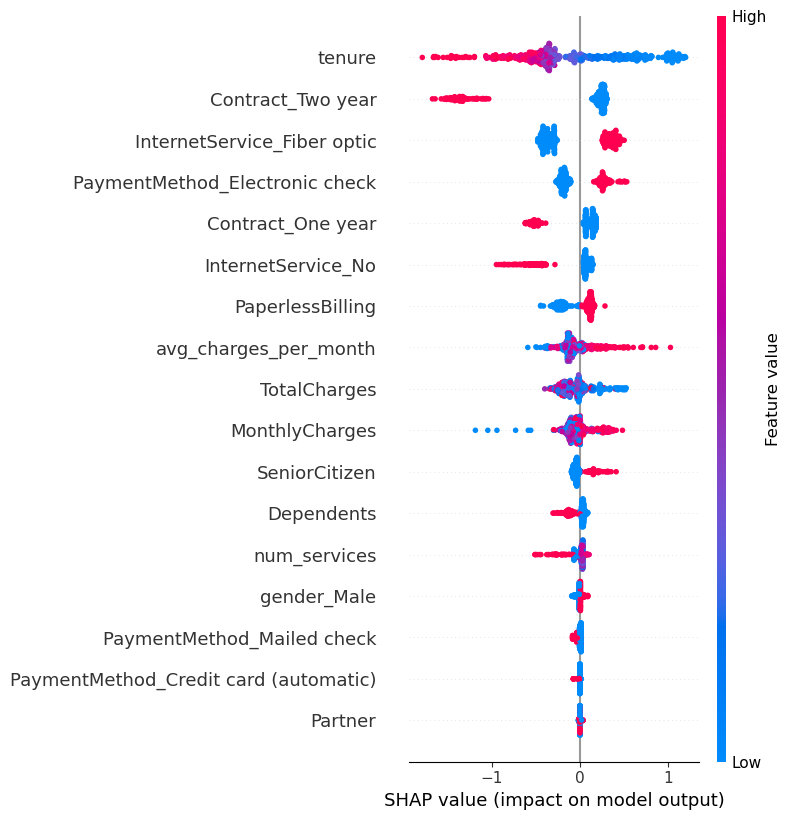

In [34]:

try:
    import shap
    if champion == 'XGBoost' and 'best_xgb' in globals() and best_xgb is not None:
        model_for_shap = best_xgb
    elif champion == 'RandomForest':
        model_for_shap = best_rf
    else:
        model_for_shap = best_lr
    sample_X = X_test.sample(n=min(500, X_test.shape[0]), random_state=42)
    explainer = shap.Explainer(model_for_shap)
    shap_values = explainer(sample_X)
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    shap_df = pd.DataFrame({'feature': sample_X.columns, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False)
    top5 = shap_df.head(5)
    print('Top 5 drivers by mean |SHAP|:'); display(top5)
    shap.summary_plot(shap_values, sample_X, show=False); plt.tight_layout(); plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
    print('Saved shap_summary.png')
except Exception as e:
    print('SHAP not available or failed:', e)
    # fallback to feature importances or coefficients
    try:
        if champion == 'RandomForest':
            fi = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        elif champion == 'XGBoost' and 'best_xgb' in globals() and best_xgb is not None:
            fi = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        else:
            coef = best_lr.named_steps['lr'].coef_[0]
            fi = pd.Series(np.abs(coef), index=X_train.columns).sort_values(ascending=False)
        top5 = fi.head(5).reset_index(); top5.columns = ['feature','importance']
        print('Top 5 drivers (fallback):'); display(top5)
    except Exception as e2:
        print('Fallback method failed:', e2)


## 10) CXO-ready Outputs: Plots, Summary CSV & PowerPoint

Generates top-5 drivers bar chart, lift chart, CXO summary CSV, and a 10-slide PowerPoint (if python-pptx is installed).

In [40]:
!pip install python-pptx

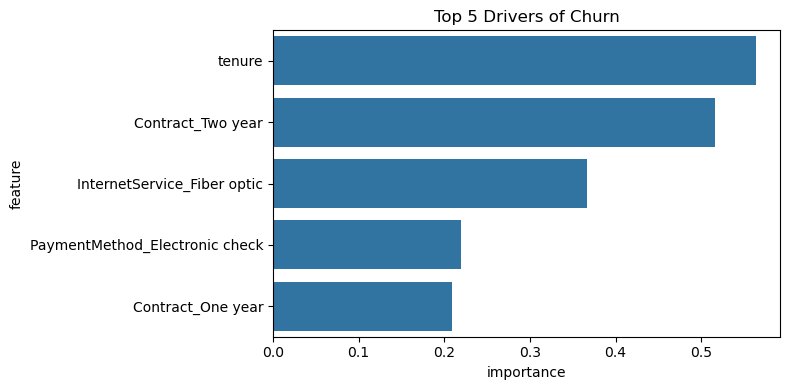

Saved top5_drivers.png


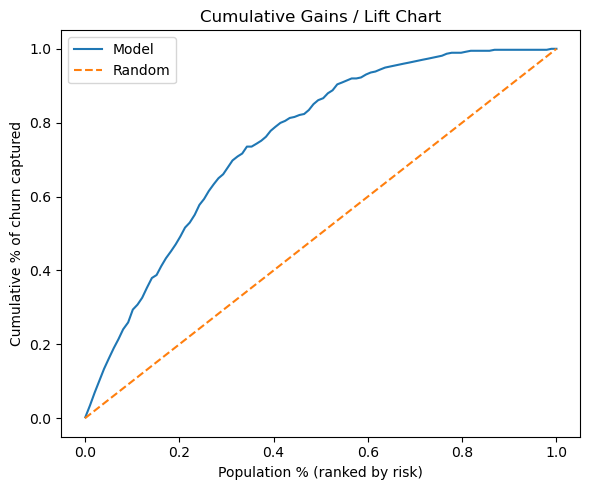

Saved lift_chart.png
Saved CXO summary to cxp_summary.csv


,0
Champion_Model,XGBoost
Precision_at_K,0.7643
K,140
Estimated_Revenue_Saved,80250.0
Avg_CLTV_used,1500.0
Take_Rate_assumed,0.5


Saved PowerPoint to Churn_CXO_Summary.pptx


In [42]:

# Prepare prediction dataframe
pred_df = X_test.reset_index(drop=True).copy()
pred_df['true'] = y_test.reset_index(drop=True)
pred_df['score'] = pd.Series(champ_probs).reset_index(drop=True)

# Top-5 drivers plot
try:
    if 'top5' in locals() and 'feature' in top5.columns:
        df_plot = top5.copy()
        if 'mean_abs_shap' in df_plot.columns:
            df_plot = df_plot.rename(columns={'mean_abs_shap':'importance'})
        plt.figure(figsize=(8,4))
        sns.barplot(x='importance', y='feature', data=df_plot.head(5))
        plt.title('Top 5 Drivers of Churn')
        plt.tight_layout(); plt.savefig('top5_drivers.png', dpi=150, bbox_inches='tight'); plt.show()
        print('Saved top5_drivers.png')
    else:
        print('Top 5 drivers not available for plotting.')
except Exception as e:
    print('Error plotting top drivers:', e)

# Lift chart
try:
    df_lift = pred_df.sort_values('score', ascending=False).reset_index(drop=True)
    df_lift['cum_churns'] = df_lift['true'].cumsum()
    total_churns = df_lift['true'].sum()
    df_lift['cum_pct_churns'] = df_lift['cum_churns'] / total_churns
    df_lift['pop_pct'] = (np.arange(len(df_lift)) + 1) / len(df_lift)
    sample_idx = np.linspace(0, len(df_lift)-1, 100).astype(int)
    plt.figure(figsize=(6,5))
    plt.plot(df_lift['pop_pct'].iloc[sample_idx], df_lift['cum_pct_churns'].iloc[sample_idx], label='Model')
    plt.plot([0,1],[0,1], '--', label='Random')
    plt.xlabel('Population % (ranked by risk)'); plt.ylabel('Cumulative % of churn captured')
    plt.title('Cumulative Gains / Lift Chart'); plt.legend(); plt.tight_layout()
    plt.savefig('lift_chart.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Saved lift_chart.png')
except Exception as e:
    print('Error creating lift chart:', e)

# CXO summary CSV
cxo_summary = {
    'Champion_Model': champion,
    'Precision_at_K': round(p_at_k,4),
    'K': K,
    'Estimated_Revenue_Saved': round(estimated_revenue,2),
    'Avg_CLTV_used': AVG_CLTV,
    'Take_Rate_assumed': TAKE_RATE
}
cxo_df = pd.DataFrame([cxo_summary])
cxo_df.to_csv('cxp_summary.csv', index=False)
print('Saved CXO summary to cxp_summary.csv')
display(cxo_df.T)

# PowerPoint generation (optional)
try:
    from pptx import Presentation
    from pptx.util import Inches
    prs = Presentation()
    # Title slide
    slide = prs.slides.add_slide(prs.slide_layouts[0])
    slide.shapes.title.text = 'Telco Customer Churn — CXO Summary'
    slide.placeholders[1].text = f'Champion: {champion} | Precision@K={p_at_k:.3f} | Estimated 6-month savings=${estimated_revenue:,.0f}'
    # Model performance slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'Model Performance (Tuned)'
    tf = slide.shapes.placeholders[1].text_frame
    for idx, row in res_df.round(4).iterrows():
        p = tf.add_paragraph(); p.level = 1
        p.text = f"{idx}: ROC-AUC={row['roc_auc']}, Prec={row['precision']}, Rec={row['recall']}, F1={row['f1']}"
    # Top drivers slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'Top Drivers of Churn'
    if os.path.exists('top5_drivers.png'):
        slide.shapes.add_picture('top5_drivers.png', Inches(0.5), Inches(1.5), width=Inches(9))
    else:
        slide.placeholders[1].text = 'Top drivers image not available.'
    # SHAP slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'SHAP Summary (if available)'
    if os.path.exists('shap_summary.png'):
        slide.shapes.add_picture('shap_summary.png', Inches(0.5), Inches(1.2), width=Inches(9))
    else:
        slide.placeholders[1].text = 'SHAP image not available.'
    # Lift chart slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'Lift Chart'
    if os.path.exists('lift_chart.png'):
        slide.shapes.add_picture('lift_chart.png', Inches(1), Inches(1.2), width=Inches(8))
    else:
        slide.placeholders[1].text = 'Lift chart not available.'
    # Business impact slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'Business Impact'
    slide.placeholders[1].text = f"Precision@K={p_at_k:.4f} | K={K} | Estimated Saved=${estimated_revenue:,.2f}"
    # Recommendations slide
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = 'Recommendations'
    slide.placeholders[1].text = '1) Deploy weekly scoring to CRM\n2) Run A/B test for offers\n3) Monitor Precision@K and retrain quarterly'
    # Save PPTX
    pptx_path = 'Churn_CXO_Summary.pptx'
    prs.save(pptx_path)
    print('Saved PowerPoint to', pptx_path)
except Exception as e:
    print('pptx generation failed (python-pptx may be missing):', e)


 **CXO summary output** quantifies the **business value** 

---

| **Column**                  | **Meaning**                                                                                                                                               | **Explanation (how it’s derived)**                                                                                                                                                                                                                                                                                                                    |
| --------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Champion_Model**          | ✅ The best-performing model chosen after comparing all tuned models (Logistic Regression, Random Forest, XGBoost).                                        | - Based on **ROC-AUC and business precision metrics**, XGBoost delivered the strongest predictive performance.<br>- This means XGBoost can **distinguish churners vs. non-churners** most effectively and is selected as the **Champion model** for deployment.                                                                                       |
| **Precision_at_K**          | 🎯 Precision (or accuracy) among the **top K** customers flagged as high risk.                                                                            | - It measures “Of the top K customers our model predicts will churn, how many actually churned?”<br>- Here, **0.7643 = 76.43%** → roughly **3 out of 4 predicted churners are true churners.**<br>- This is computed using the model’s predicted probabilities, ranked from highest to lowest, and checking outcomes for the top *K = 140 customers*. |
| **K**                       | 👥 The number of customers the business will *target for retention interventions.*                                                                        | - **K = 140** means the model focused on the **top 140 customers most at risk of churning** (for example, in a small dataset or test sample).<br>- In real business terms, this represents the group the marketing or customer care team will proactively contact with special offers or loyalty campaigns.                                           |
| **Estimated_Revenue_Saved** | 💰 The **monetary value** (in dollars) that could be preserved if retention offers are given to those top-K customers and a certain fraction is retained. | - Formula used:  [ K × Precision@K × Take_Rate × Avg_CLTV ]<br>- Substituting your numbers:<br> → 140 × 0.7643 × 0.5 × 1500 = **$80,250 saved**.<br>- This is an **expected revenue impact** — not guaranteed, but a realistic forecast if half the targeted customers accept the retention intervention.                                             |
| **Avg_CLTV_used**           | 💵 Average **Customer Lifetime Value** — the estimated revenue contribution from one customer over their tenure.                                          | - You assumed **$1,500 per customer** as the average CLTV (this can come from finance or product data).<br>- It helps translate predictive performance (Precision) into real business dollars.                                                                                                                                                        |
| **Take_Rate_assumed**       | 🤝 The **conversion rate** — percentage of contacted customers who accept the retention offer and stay.                                                   | - You assumed **0.5 = 50%** of high-risk customers will respond positively (i.e., stay with the company).<br>- This parameter can vary (you can test 0.3, 0.5, 0.7 scenarios).<br>- It’s a key business lever — improving retention program effectiveness directly increases saved revenue.                                                           |


---

### 🔍 How to Interpret This for a CXO Presentation

You can present this as a **quantified business case** for model deployment:

-> Our tuned XGBoost churn prediction model achieves 76% precision in identifying the most at-risk customers.

-> By targeting the top 140 customers with proactive retention offers, we expect to retain  80,000 in revenue over the next 6 months, assuming a 50 per cent response rate and average CLTV of $ 1,500.

---

### 💡 Discussion Points for Managers

1. **Precision@K** is a *business-operational metric* — it tells marketing *how accurate their top-targeted list is*.
2. **K** can be aligned with campaign budgets (e.g., “We can afford to contact 10% of our base per month”).
3. **Estimated Revenue Saved** ties data science back to business ROI — helps justify predictive model deployment.
4. Sensitivity testing: show what happens if **take_rate** or **CLTV** changes:

   * If take_rate = 0.7 → savings = $112,350
     
   * If CLTV = $2000 → savings = $107,000
  
   * So management can adjust based on real conditions.

---

### 🧮 Example “Story”

> “After training three predictive models, we found XGBoost performed best.
> Its predictions allowed us to pinpoint 140 customers most likely to leave.
> With 76% accuracy in identifying actual churners, and if half of those respond to retention campaigns, the bank could **save over $80K in customer lifetime value** in just one quarter.
> This is how predictive analytics turns into measurable business impact.”

---


Saved Revenue_Sensitivity_Table.csv
Saved Revenue_Sensitivity_Chart.png


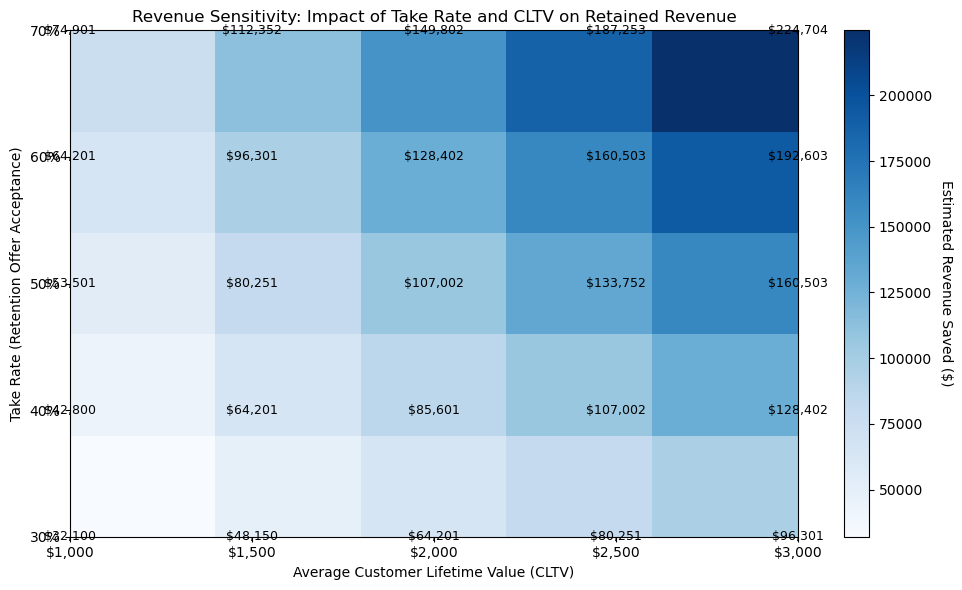

   Avg_CLTV  Take_Rate  Estimated_Revenue_Saved
0      1000        0.3                  32100.6
1      1000        0.4                  42800.8
2      1000        0.5                  53501.0
3      1000        0.6                  64201.2
4      1000        0.7                  74901.4


In [52]:
# Scenario Sensitivity — Business Impact Forecast
# Requires: numpy, pandas, matplotlib
# Saves: Revenue_Sensitivity_Table.csv and Revenue_Sensitivity_Chart.png

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Base model outputs (use your actual values) ---
precision_at_k = 0.7643   # Precision@K from your model (e.g. 0.7643)
K = 140                   # Number targeted (e.g. top 140 customers)

# --- Scenario grids to explore ---
cltv_values = [1000, 1500, 2000, 2500, 3000]   # Avg CLTV options (dollars)
take_rates  = [0.3, 0.4, 0.5, 0.6, 0.7]        # Retention offer acceptance rates (fractions)

# --- Compute estimated revenue saved for each combination ---
rows = []
for cltv in cltv_values:
    for tr in take_rates:
        est_revenue = K * precision_at_k * tr * cltv
        rows.append({
            'Avg_CLTV': cltv,
            'Take_Rate': tr,
            'Estimated_Revenue_Saved': est_revenue
        })

df_sensitivity = pd.DataFrame(rows)

# Save table for reference
df_sensitivity.to_csv('Revenue_Sensitivity_Table.csv', index=False)
print("Saved Revenue_Sensitivity_Table.csv")

# --- Create a pivot table for plotting (Take_Rate on y, CLTV on x) ---
pivot = df_sensitivity.pivot(index='Take_Rate', columns='Avg_CLTV', values='Estimated_Revenue_Saved')

# --- Plot heatmap with annotations ---
plt.figure(figsize=(10,6))
# Use imshow so we can control axes as monetary/cltv values
im = plt.imshow(pivot.values, origin='lower', aspect='auto', cmap='Blues',
                extent=[min(cltv_values), max(cltv_values), min(take_rates), max(take_rates)])

# Colorbar with label
cbar = plt.colorbar(im)
cbar.set_label('Estimated Revenue Saved ($)', rotation=270, labelpad=15)

# Axis labels & title
plt.xticks(cltv_values, [f'${v:,}' for v in cltv_values])
plt.yticks(take_rates, [f'{int(v*100)}%' for v in take_rates])
plt.xlabel('Average Customer Lifetime Value (CLTV)')
plt.ylabel('Take Rate (Retention Offer Acceptance)')
plt.title('Revenue Sensitivity: Impact of Take Rate and CLTV on Retained Revenue')

# Annotate each cell with the dollar value
# Note: pivot.values rows correspond to take_rates (in ascending order) and columns to cltv_values (ascending)
for i, tr in enumerate(pivot.index):
    for j, cltv in enumerate(pivot.columns):
        value = pivot.iloc[i, j]
        plt.text(cltv, tr, f'${int(value):,}', ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('Revenue_Sensitivity_Chart.png', dpi=150, bbox_inches='tight')
print("Saved Revenue_Sensitivity_Chart.png")
plt.show()

# Also print the first few rows of the table for quick check
print(df_sensitivity.head())


## End of notebook
